# Fruit AI Clustering

## 1. Importation des bibliothèques

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import joblib
import mlflow
import mlflow.sklearn

## 2. Chargement du dataset

In [9]:
df = pd.read_csv(
    'fruits.csv',
    header=None,
    names=['Feature1', 'Feature2']
)

df.head()

,Feature1,Feature2
0,43.70,38.57
1,22.47,6.41
2,26.09,8.72
3,36.18,27.45
4,18.24,1.89


## 3. Exploration des données

In [10]:
print ("Informations generales")
df.info()

Informations generales
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Feature1  400 non-null    float64
 1   Feature2  400 non-null    float64
dtypes: float64(2)
memory usage: 6.4 KB


In [11]:
print ("Vérification des valeurs manquantes")
df.isnull().sum()

Vérification des valeurs manquantes


,0
Feature1,0
Feature2,0


In [12]:
print("Statistiques descriptives")
df.describe()

Statistiques descriptives


,Feature1,Feature2
count,400.000000,400.000000
mean,35.168675,32.689875
std,12.757083,31.083175
min,17.030000,1.090000
25%,24.120000,7.165000
50%,31.975000,17.995000
75%,46.552500,53.245000
max,58.920000,109.910000


Visualisation des distributions


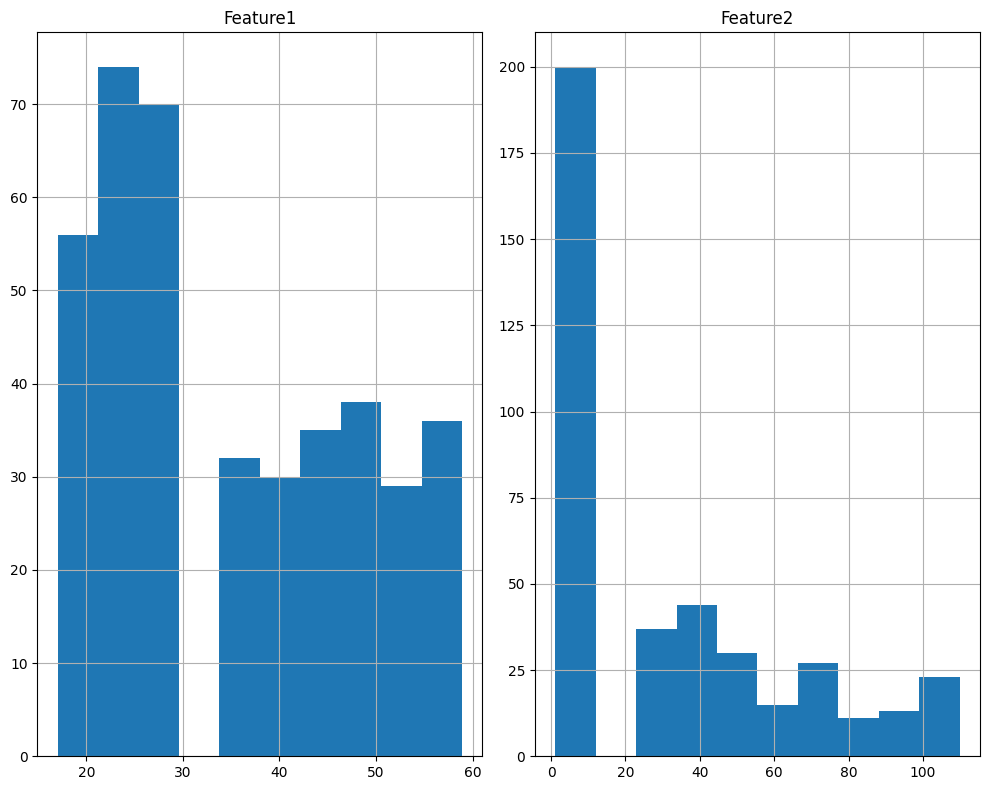

In [13]:
print("Visualisation des distributions")
df.hist(figsize=(10,8))
plt.tight_layout()
plt.show()

## 4. Sélection des features

In [14]:
X = df
X.head()

,Feature1,Feature2
0,43.70,38.57
1,22.47,6.41
2,26.09,8.72
3,36.18,27.45
4,18.24,1.89


## 5. Normalisation des données

In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:5]

array([[ 0.66958952,  0.1894108 ],
       [-0.99666813, -0.84652828],
       [-0.71254883, -0.77211848],
       [ 0.07937485, -0.16878704],
       [-1.32866388, -0.99212669]])

## 6. Trouver le meilleur nombre de clusters

### Elbow Method

In [16]:
inertias = []
K_range = range(1, 11)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    inertias.append(model.inertia_)

### Visualisation Elbow Method

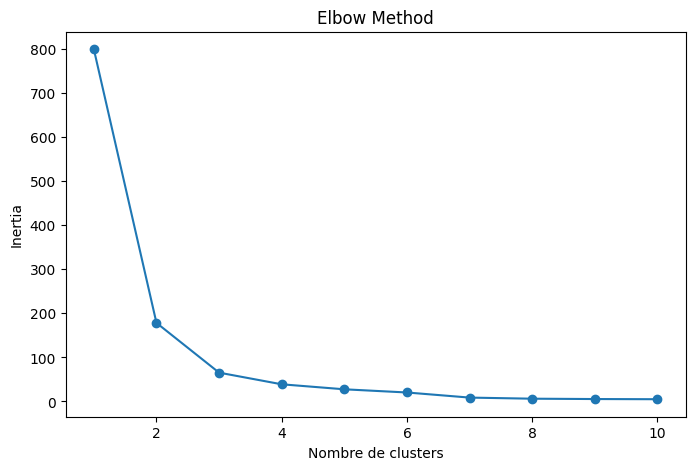

In [17]:
plt.figure(figsize=(8,5))
plt.plot(K_range, inertias, marker='o')
plt.xlabel('Nombre de clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

## 7. Modèles de clustering

In [18]:
from sklearn.cluster import (
    KMeans,
    DBSCAN,
    AgglomerativeClustering
)

models = {
    'KMeans': KMeans(n_clusters=3, random_state=42),
    'Agglomerative': AgglomerativeClustering(n_clusters=3),
    'DBSCAN': DBSCAN(eps=0.5)
}

### 8. Comparaison des modèles

In [19]:
results = []

mlflow.set_experiment('fruit-clustering')

for name, model in models.items():
    with mlflow.start_run(run_name=name):
        clusters = model.fit_predict(X_scaled)
        unique_clusters = len(set(clusters))
        if unique_clusters > 1:
            score = silhouette_score(X_scaled, clusters)
            mlflow.log_param('model_name', name)
            mlflow.log_metric('silhouette_score', score)
            if name == 'KMeans':
                mlflow.log_metric('inertia', model.inertia_)

            results.append({
                'model': name,
                'score': score
            })
            print(f'{name} score : {score}')

        else:
            print(f'{name} a produit un seul cluster')

2026/05/30 13:34:35 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/30 13:34:35 INFO mlflow.store.db.utils: Updating database tables
2026/05/30 13:34:37 INFO mlflow.tracking.fluent: Experiment with name 'fruit-clustering' does not exist. Creating a new experiment.


KMeans score : 0.7011027379932304
Agglomerative score : 0.7011027379932304
DBSCAN score : 0.6662087728258996


## 9. Tableau des résultats

In [20]:
results_df = pd.DataFrame(results)
results_df

,model,score
0,KMeans,0.701103
1,Agglomerative,0.701103
2,DBSCAN,0.666209


## 10. Choisir le meilleur modèle

In [21]:
best_model_name = results_df.sort_values(
    by='score',
    ascending=False
).iloc[0]['model']

print('Meilleur modèle :', best_model_name)

Meilleur modèle : KMeans


## 11. Entraîner le meilleur modèle final

In [22]:
best_model = KMeans(n_clusters=3, random_state=42)
clusters = best_model.fit_predict(X_scaled)

## 12. Ajouter les clusters au dataset

In [23]:
df['cluster'] = clusters
df.head()

,Feature1,Feature2,cluster
0,43.70,38.57,0
1,22.47,6.41,1
2,26.09,8.72,1
3,36.18,27.45,0
4,18.24,1.89,1


## 13. Évaluation du modèle final

In [24]:
score = silhouette_score(X_scaled, clusters)
print('Silhouette Score :', score)

Silhouette Score : 0.7011027379932304


## 14. Visualisation des clusters avec PCA

In [25]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

### Scatter Plot

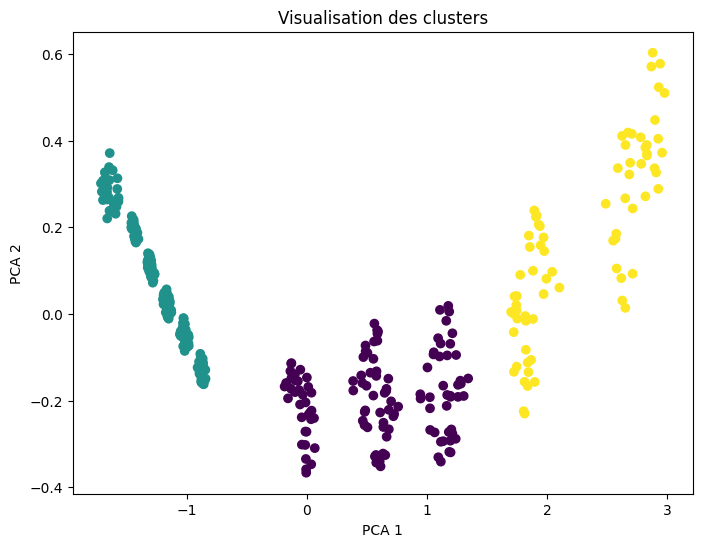

In [26]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters
)

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Visualisation des clusters')

plt.show()

## 15. Sauvegarde du meilleur modèle

In [28]:
joblib.dump(best_model, 'fruit_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print('Modèle sauvegardé !')

Modèle sauvegardé !
